In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Online Retail dataset
url = "https://github.com/dbdmg/data-science-lab/raw/master/datasets/online_retail.csv"

df = pd.read_csv(url, encoding="latin1")

print("Dataset Loaded Successfully!")
print("Original Dataset Shape:", df.shape)

display(df.head())

print("\nDATASET INFORMATION")
df.info()

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove invalid transactions
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# ------------------------------------------
# Feature Engineering
# ------------------------------------------

# Calculate Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Extract date features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.strftime("%B")
df["Date"] = df["InvoiceDate"].dt.date

print("\nFEATURE ENGINEERING COMPLETED!")

display(
    df[
        [
            "InvoiceNo",
            "CustomerID",
            "InvoiceDate",
            "Quantity",
            "UnitPrice",
            "Revenue",
            "Year",
            "Month"
        ]
    ].head()
)

print("\nCleaned Dataset Shape:", df.shape)

Dataset Loaded Successfully!
Original Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

FEATURE ENGINEERING COMPLETED!


,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,Revenue,Year,Month
0,536365,17850.0,2010-12-01 08:26:00,6,2.55,15.30,2010,12
1,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34,2010,12
2,536365,17850.0,2010-12-01 08:26:00,8,2.75,22.00,2010,12
3,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34,2010,12
4,536365,17850.0,2010-12-01 08:26:00,6,3.39,20.34,2010,12



Cleaned Dataset Shape: (392692, 13)


MONTHLY REVENUE


Revenue
Year Month             
2010 12      570422.730
2011 1       568101.310
     2       446084.920
     3       594081.760
     4       468374.331
     5       677355.150
     6       660046.050
     7       598962.901
     8       644051.040
     9       950690.202
     10     1035642.450
     11     1156205.610
     12      517190.440


TOP 10 CUSTOMERS BY REVENUE


,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84



TOP 10 COUNTRIES BY REVENUE


,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


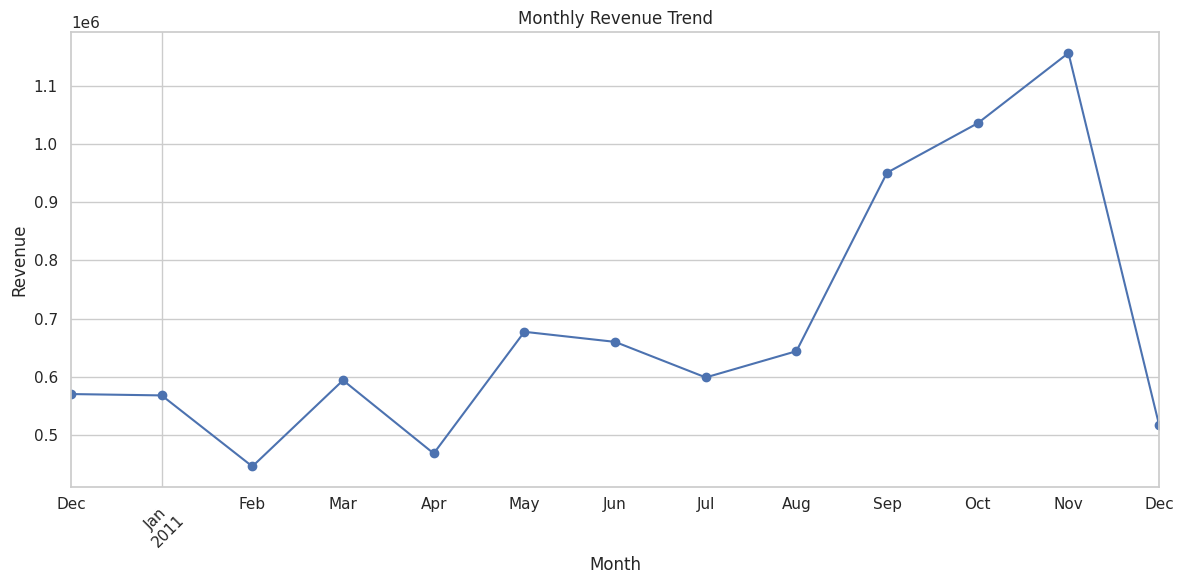

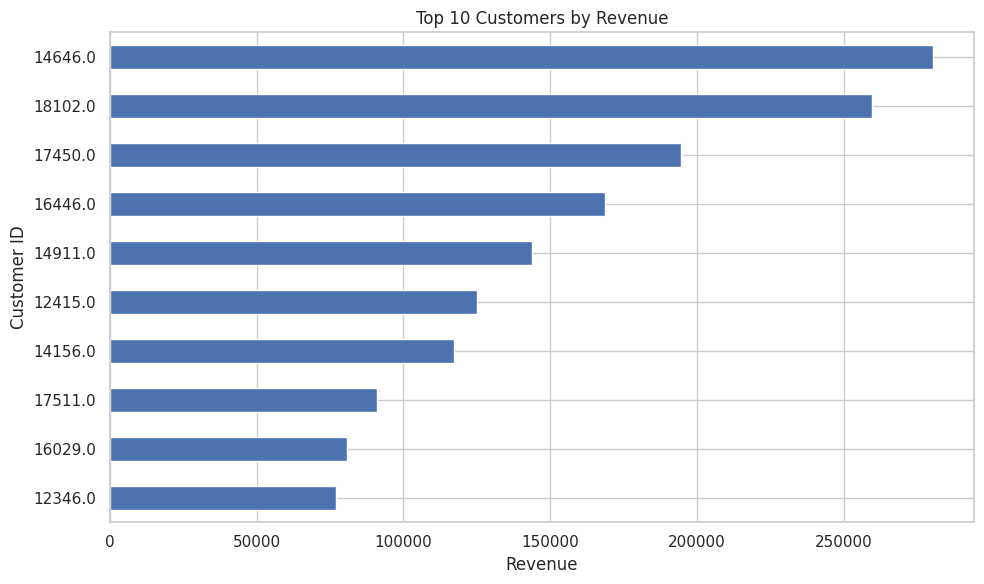


PIVOT TABLES AND SALES TREND ANALYSIS COMPLETED!


In [10]:
# ==========================================
# STEP 3 - Pivot Tables & Sales Trends
# ==========================================

# 1. Monthly Revenue Analysis
monthly_revenue = df.pivot_table(
    index=["Year", "Month"],
    values="Revenue",
    aggfunc="sum"
)

print("MONTHLY REVENUE")
display(monthly_revenue)


# 2. Top 10 Customers by Revenue
top_customers = df.groupby("CustomerID")["Revenue"].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print("\nTOP 10 CUSTOMERS BY REVENUE")
display(top_customers)


# 3. Revenue by Country
country_revenue = df.groupby("Country")["Revenue"] \
                    .sum() \
                    .sort_values(ascending=False) \
                    .head(10)

print("\nTOP 10 COUNTRIES BY REVENUE")
display(country_revenue)


# 4. Revenue Trend Chart
monthly_revenue_plot = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Revenue"].sum()

plt.figure(figsize=(12, 6))

monthly_revenue_plot.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Top Customer Chart
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


print("\nPIVOT TABLES AND SALES TREND ANALYSIS COMPLETED!")

CUSTOMER ANALYSIS


,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
CustomerID,,,,
14646.0,280206.02,73,196915,3838.438630
18102.0,259657.30,60,64124,4327.621667
17450.0,194390.79,46,69973,4225.886739
16446.0,168472.50,2,80997,84236.250000
14911.0,143711.17,201,80240,714.980945
12415.0,124914.53,21,77374,5948.310952
14156.0,117210.08,55,57768,2131.092364
17511.0,91062.38,31,64549,2937.496129
16029.0,80850.84,63,40108,1283.346667



CUSTOMER SEGMENTS


,count
Customer_Segment,
Low Value,2674
Medium Value,1390
High Value,274



REVENUE BY CUSTOMER SEGMENT


,Total_Revenue
Customer_Segment,
High Value,4790654.330
Medium Value,2991432.261
Low Value,1105122.303


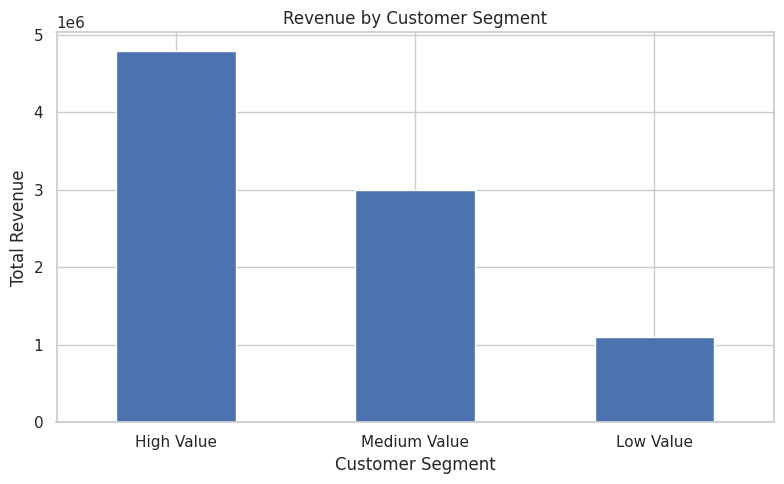


ACTIONABLE BUSINESS RECOMMENDATIONS

1. HIGH-VALUE CUSTOMERS
   - Provide loyalty rewards and exclusive offers.
   - Give personalized product recommendations.
   - Focus on retaining these customers.

2. MEDIUM-VALUE CUSTOMERS
   - Use targeted discounts to increase their spending.
   - Recommend related and premium products.
   - Encourage repeat purchases.

3. LOW-VALUE CUSTOMERS
   - Use introductory offers and promotional campaigns.
   - Encourage first-time and repeat purchases.
   - Identify products that can increase order value.

4. SALES TREND
   - Monitor monthly revenue trends.
   - Increase marketing during high-performing periods.
   - Investigate low-revenue months and improve promotions.

5. TOP CUSTOMERS AND COUNTRIES
   - Focus customer retention strategies on high-revenue customers.
   - Strengthen marketing in high-performing countries.

TASK 3 ANALYSIS COMPLETED SUCCESSFULLY!


In [11]:
# ==========================================
# STEP 4 - Customer Segmentation
# ==========================================

# Calculate customer-level metrics
customer_analysis = df.groupby("CustomerID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Quantity=("Quantity", "sum")
)

# Average order value
customer_analysis["Average_Order_Value"] = (
    customer_analysis["Total_Revenue"] /
    customer_analysis["Total_Orders"]
)

# Sort customers by revenue
customer_analysis = customer_analysis.sort_values(
    "Total_Revenue",
    ascending=False
)

print("CUSTOMER ANALYSIS")
display(customer_analysis.head(10))


# ------------------------------------------
# Customer Segments
# ------------------------------------------

def customer_segment(row):
    if row["Total_Revenue"] >= 5000:
        return "High Value"
    elif row["Total_Revenue"] >= 1000:
        return "Medium Value"
    else:
        return "Low Value"


customer_analysis["Customer_Segment"] = customer_analysis.apply(
    customer_segment,
    axis=1
)

print("\nCUSTOMER SEGMENTS")
display(
    customer_analysis["Customer_Segment"]
    .value_counts()
)


# ------------------------------------------
# Segment Revenue
# ------------------------------------------

segment_revenue = customer_analysis.groupby(
    "Customer_Segment"
)["Total_Revenue"].sum().sort_values(ascending=False)

print("\nREVENUE BY CUSTOMER SEGMENT")
display(segment_revenue)


# ------------------------------------------
# Segment Visualization
# ------------------------------------------

plt.figure(figsize=(8, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------
# Business Recommendations
# ------------------------------------------

print("\n" + "=" * 60)
print("ACTIONABLE BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. HIGH-VALUE CUSTOMERS
   - Provide loyalty rewards and exclusive offers.
   - Give personalized product recommendations.
   - Focus on retaining these customers.

2. MEDIUM-VALUE CUSTOMERS
   - Use targeted discounts to increase their spending.
   - Recommend related and premium products.
   - Encourage repeat purchases.

3. LOW-VALUE CUSTOMERS
   - Use introductory offers and promotional campaigns.
   - Encourage first-time and repeat purchases.
   - Identify products that can increase order value.

4. SALES TREND
   - Monitor monthly revenue trends.
   - Increase marketing during high-performing periods.
   - Investigate low-revenue months and improve promotions.

5. TOP CUSTOMERS AND COUNTRIES
   - Focus customer retention strategies on high-revenue customers.
   - Strengthen marketing in high-performing countries.
""")

print("=" * 60)
print("TASK 3 ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 60)